In [2]:
#importing the package
import snotelpy as sp

import numpy as np

import matplotlib.pyplot as plt
import xarray as xr
from scipy import stats



<xarray.Dataset> Size: 6kB
Dimensions:  (time: 366, station: 1)
Coordinates:
  * time     (time) datetime64[us] 3kB 2024-10-01 2024-10-02 ... 2025-10-01
  * station  (station) <U11 44B '663:CO:SNTL'
Data variables:
    WTEQ     (time, station) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.1 0.0 0.0
Attributes:
    source:    USDA NRCS AWDB REST API
    network:   SNOTEL
    duration:  DAILY


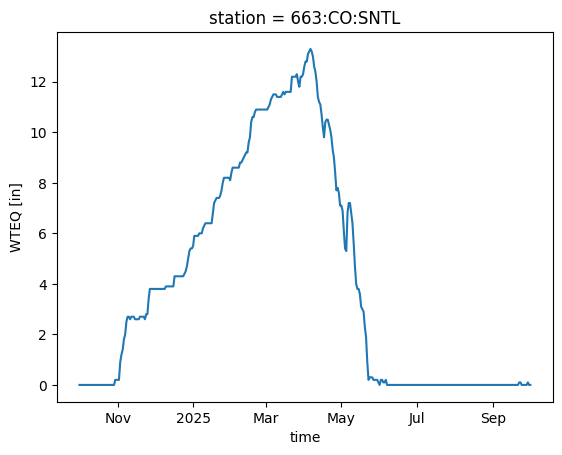

In [3]:
# Lets get a dataset for 1 station 
'''
Fetch Data Takes in a Station Triplet as a list, stationID:statecode:networkcode(SNTL, for now?)
we can choose what data we want by the Element, most commonly is SWE witch the code for this is WTEQ
we aslo have frequency of reported data(default is Daily)
and time ranges(default from snotel)---> had some problems with this while coding
'''
station_triplet = ["663:CO:SNTL"] #at Niwot
elements = ["WTEQ"]

ds = sp.fetch_snotel(station_triplet, elements=elements, duration="DAILY", start_date= "2024-10-01", end_date= "2025-10-01")
print(ds)

station_0 = ds['WTEQ'].isel(station = 0)
station_0.plot()

plt.show()

In [4]:
#get_stations dataframes
gdf = sp.get_stations(county_name="Boulder",returnType='gpd')
# df = sp.get_stations(county_name="Boulder")
print(gdf)
# print(df)

  stationTriplet stationId stateCode networkCode             name dcoCode  \
0    412:CO:SNTL       412        CO        SNTL    Copeland Lake      CO   
1    564:CO:SNTL       564        CO        SNTL      Lake Eldora      CO   
2    663:CO:SNTL       663        CO        SNTL            Niwot      CO   
3   1251:CO:SNTL      1251        CO        SNTL         Sawtooth      CO   
4    838:CO:SNTL       838        CO        SNTL  University Camp      CO   
5   1042:CO:SNTL      1042        CO        SNTL       Wild Basin      CO   

  countyName           huc  elevation  latitude  longitude  dataTimeZone  \
0    Boulder  101900050202     8570.0  40.20733 -105.56950          -8.0   
1    Boulder  101900050402     9700.0  39.93659 -105.59031          -8.0   
2    Boulder  101900050401     9940.0  40.03581 -105.54520          -8.0   
3    Boulder  101900050102     9640.0  40.13632 -105.58486          -8.0   
4    Boulder  101900050401    10330.0  40.03307 -105.57562          -8.0   
5   

141
['916:MT:SNTL', '307:MT:SNTL', '309:WY:SNTL', '318:MT:SNTL', '322:CO:SNTL', '325:WY:SNTL', '326:WY:SNTL', '328:MT:SNTL', '931:WY:SNTL', '347:MT:SNTL', '1161:CO:SNTL', '1119:WY:SNTL', '350:WY:SNTL', '354:SD:SNTL', '355:MT:SNTL', '358:WY:SNTL', '360:MT:SNTL', '363:MT:SNTL', '365:MT:SNTL', '367:WY:SNTL', '938:CO:SNTL', '377:WY:SNTL', '981:MT:SNTL', '379:WY:SNTL', '381:MT:SNTL', '384:WY:SNTL', '385:MT:SNTL', '389:WY:SNTL', '1130:WY:SNTL', '1046:WY:SNTL', '402:WY:SNTL', '403:MT:SNTL', '405:WY:SNTL', '982:WY:SNTL', '407:MT:SNTL', '408:CO:SNTL', '412:CO:SNTL', '1045:WY:SNTL', '427:MT:SNTL', '919:MT:SNTL', '436:MT:SNTL', '437:MT:SNTL', '438:CO:SNTL', '923:WY:SNTL', '448:MT:SNTL', '451:WY:SNTL', '458:MT:SNTL', '1105:MT:SNTL', '936:CO:SNTL', '1316:MT:SNTL', '472:WY:SNTL', '480:MT:SNTL', '487:MT:SNTL', '501:WY:SNTL', '512:WY:SNTL', '525:WY:SNTL', '531:CO:SNTL', '1122:CO:SNTL', '935:CO:SNTL', '1287:MT:SNTL', '551:CO:SNTL', '560:WY:SNTL', '564:CO:SNTL', '568:MT:SNTL', '571:WY:SNTL', '1134:WY:SN

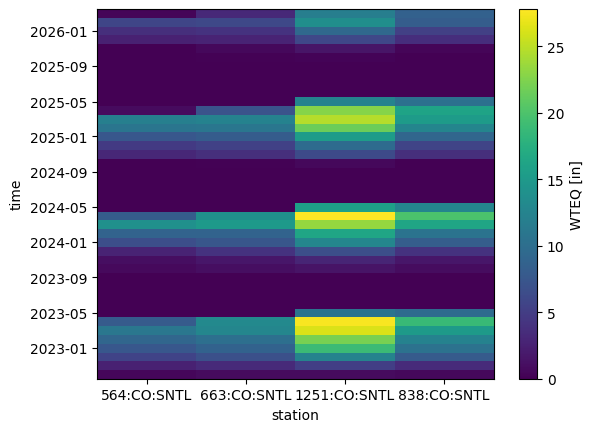

In [5]:
#sort by Huc
gdf = sp.get_stations(hucs=['10'],returnType='GPD')
list_stationtrips = gdf['stationTriplet'].tolist()
print(len(list_stationtrips))
print(list_stationtrips)
ds = sp.fetch_snotel(list_stationtrips, ["WTEQ"], "MONTHLY", start_date= "2022-10-01", include_coords= True)
print(ds)
ds['WTEQ'].sel(station = ['564:CO:SNTL', '663:CO:SNTL', '1251:CO:SNTL', '838:CO:SNTL']).plot.imshow()
plt.show()

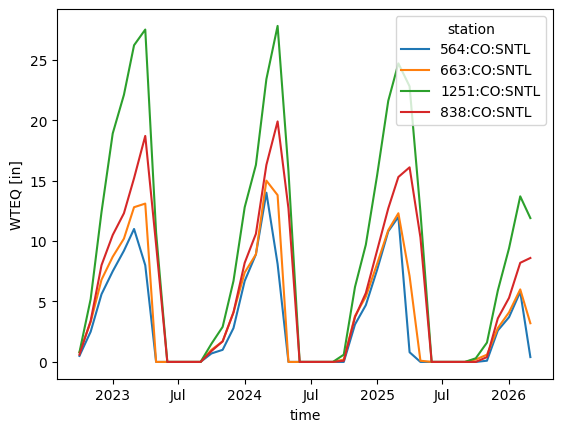

In [6]:
ds['WTEQ'].sel(station = ['564:CO:SNTL', '663:CO:SNTL', '1251:CO:SNTL', '838:CO:SNTL']).plot.line(x='time', hue='station')
plt.show()

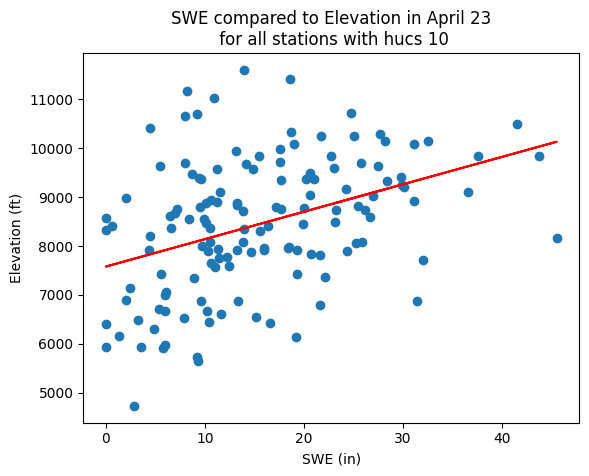

------STATS------
R^2 Value: 0.394
P Value: 1.595e-06
STD error: 11.182


In [7]:
#elevation compaison 
ds_april23 = ds['WTEQ'].sel(time = "2023-04", method = 'nearest')

y = (ds.elevation.values)
x = (ds_april23.values)
# remove NaN/inf values before fitting
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line = slope * x + intercept

plt.plot(x, slope*x + intercept,color = 'red', label = "line of best fit")
plt.scatter(x, y, label='Data Points')

plt.ylabel("Elevation (ft)")
plt.xlabel("SWE (in)")
plt.title("SWE compared to Elevation in April 23\n for all stations with hucs 10")
plt.show()

print("------STATS------") 
print(f"R^2 Value: {r_value:.3f}")
print(f"P Value: {p_value:.3e}") #the likleyness that the data occured by chance, 0.05 > Pvalue is a good indication of strong evidence 
print(f"STD error: {std_err:.3f}") #


<xarray.Dataset> Size: 8kB
Dimensions:    (time: 186, station: 2)
Coordinates:
  * time       (time) datetime64[us] 1kB 2010-10-01 2010-11-01 ... 2026-03-01
  * station    (station) <U11 88B '838:CO:SNTL' '663:CO:SNTL'
    latitude   (station) float64 16B 40.03 40.04
    longitude  (station) float64 16B -105.6 -105.5
    elevation  (station) float64 16B 1.033e+04 9.94e+03
Data variables:
    PREC       (time, station) float64 3kB 4.6 3.2 7.9 5.2 ... 9.4 15.6 12.0
    WTEQ       (time, station) float64 3kB 1.9 0.9 4.2 2.5 ... 8.2 6.0 8.6 3.2
Attributes:
    source:    USDA NRCS AWDB REST API
    network:   SNOTEL
    duration:  Monthly


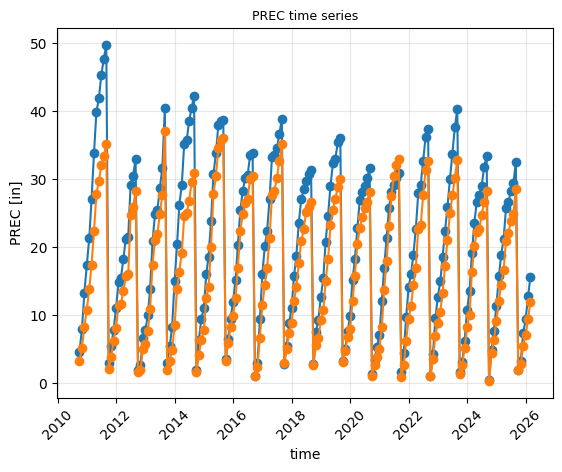

<Axes: title={'center': 'PREC time series'}, xlabel='time', ylabel='PREC [in]'>

In [8]:
#using element timeseries function with precipitation 
ds = sp.fetch_snotel(["838:CO:SNTL",'663:CO:SNTL'],['WTEQ', 'PREC'],duration="Monthly", start_date="2010-10-01", include_coords= True)
print(ds)
sp.plot.element_timeseries(ds, 'PREC')



In [9]:
#Saving Data
import snotelpy as sp
sp.save_data(ds, "snotel_example")


KeyError: 'WTEQ'